# 01 -->> IMPORT LIBRARIES

In [1]:
# ============================================================
#                 IMPORT LIBRARIES
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Style
plt.style.use("ggplot")

print("="*60)
print("Libraries Imported Successfully")
print("="*60)

Libraries Imported Successfully


# 02 --> Load Dataset

In [2]:
# ============================================================
#                  LOAD DATASET
# ============================================================

train_df = pd.read_csv("train.csv")

test_df = pd.read_csv("test.csv")

print("="*60)
print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)
print("="*60)

Training Dataset Shape : (42000, 785)
Testing Dataset Shape  : (28000, 784)


In [3]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# 03 —-> Dataset Exploration

In [4]:
# ============================================================
#               DATASET INFORMATION
# ============================================================

print("="*60)
print("Dataset Information")
print("="*60)

train_df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [5]:
# ============================================================
#            MISSING VALUES
# ============================================================

missing = train_df.isnull().sum().sum()

print(f"Total Missing Values : {missing}")

Total Missing Values : 0


In [6]:
# ============================================================
#            MISSING VALUES
# ============================================================

missing = train_df.isnull().sum().sum()

print(f"Total Missing Values : {missing}")

Total Missing Values : 0


In [7]:
# ============================================================
#          DESCRIPTIVE STATISTICS
# ============================================================

train_df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


# 04 -->> Exploratory Data Analysis (EDA)

In [8]:
# ============================================================
#          SEPARATE FEATURES AND TARGET
# ============================================================

X = train_df.drop("label", axis=1)
y = train_df["label"]

print("=" * 60)
print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")
print("=" * 60)

Features Shape : (42000, 784)
Target Shape   : (42000,)


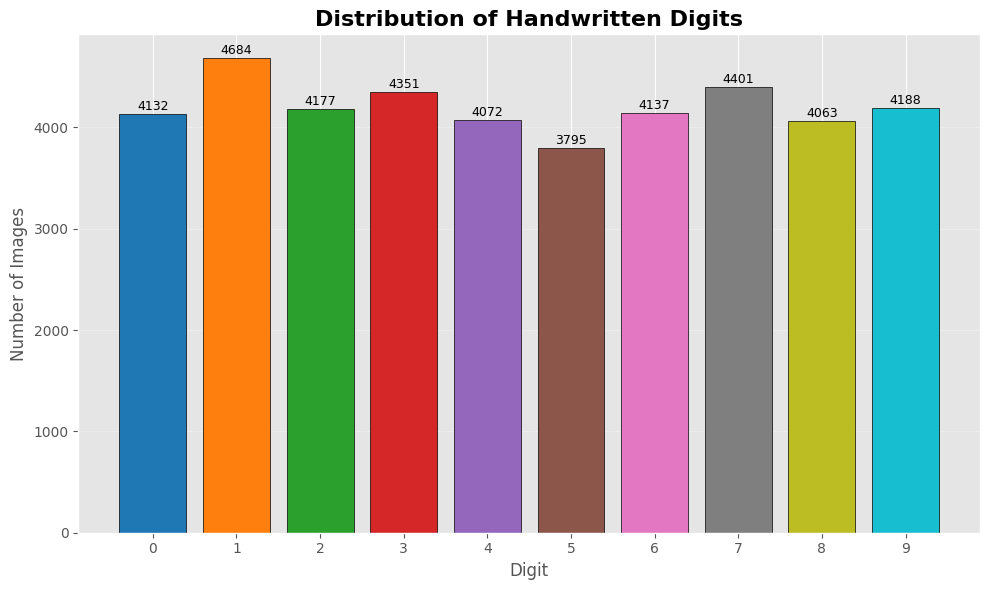

In [9]:
# ============================================================
#              DIGIT CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

colors = plt.cm.tab10(np.arange(10))

bars = plt.bar(
    y.value_counts().sort_index().index,
    y.value_counts().sort_index().values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Distribution of Handwritten Digits",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Digit")
plt.ylabel("Number of Images")

plt.xticks(range(10))

plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+40,
        int(bar.get_height()),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

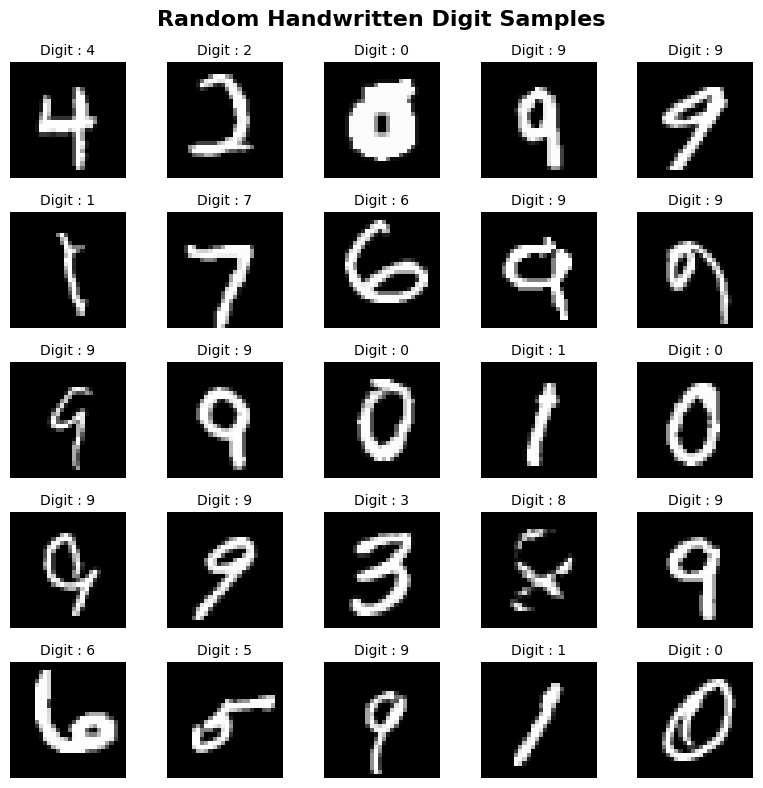

In [10]:
# ============================================================
#             RANDOM HANDWRITTEN DIGITS
# ============================================================

fig, axes = plt.subplots(5,5, figsize=(8,8))

fig.suptitle(
    "Random Handwritten Digit Samples",
    fontsize=16,
    fontweight="bold"
)

for ax in axes.flat:

    index = np.random.randint(len(train_df))

    image = X.iloc[index].values.reshape(28,28)

    label = y.iloc[index]

    ax.imshow(image, cmap="gray")

    ax.set_title(f"Digit : {label}", fontsize=10)

    ax.axis("off")

plt.tight_layout()

plt.show()

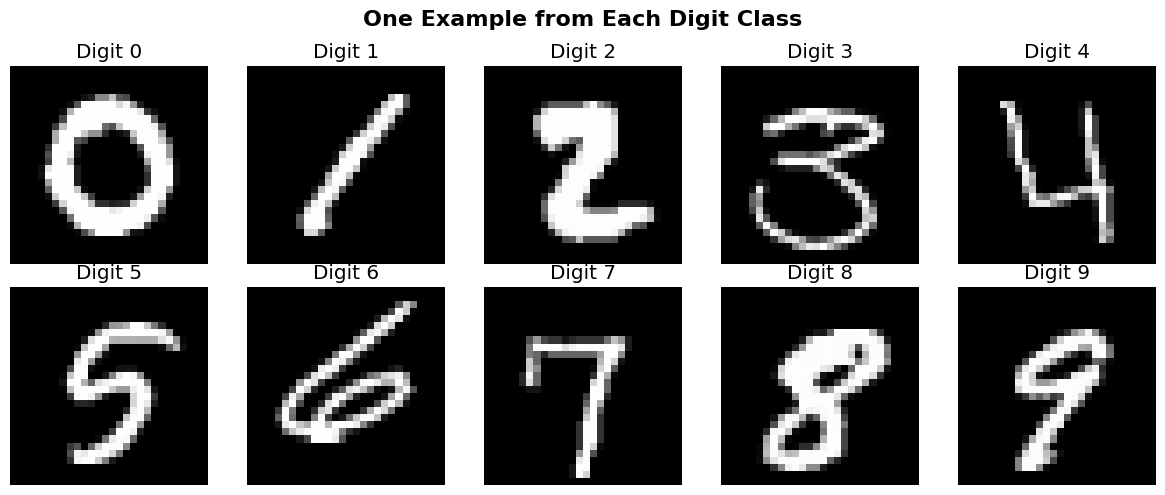

In [11]:
# ============================================================
#           ONE SAMPLE OF EACH DIGIT
# ============================================================

fig, axes = plt.subplots(2,5, figsize=(12,5))

fig.suptitle(
    "One Example from Each Digit Class",
    fontsize=16,
    fontweight="bold"
)

for digit in range(10):

    index = y[y == digit].index[0]

    image = X.loc[index].values.reshape(28,28)

    axes.flat[digit].imshow(
        image,
        cmap="gray"
    )

    axes.flat[digit].set_title(f"Digit {digit}")

    axes.flat[digit].axis("off")

plt.tight_layout()

plt.show()

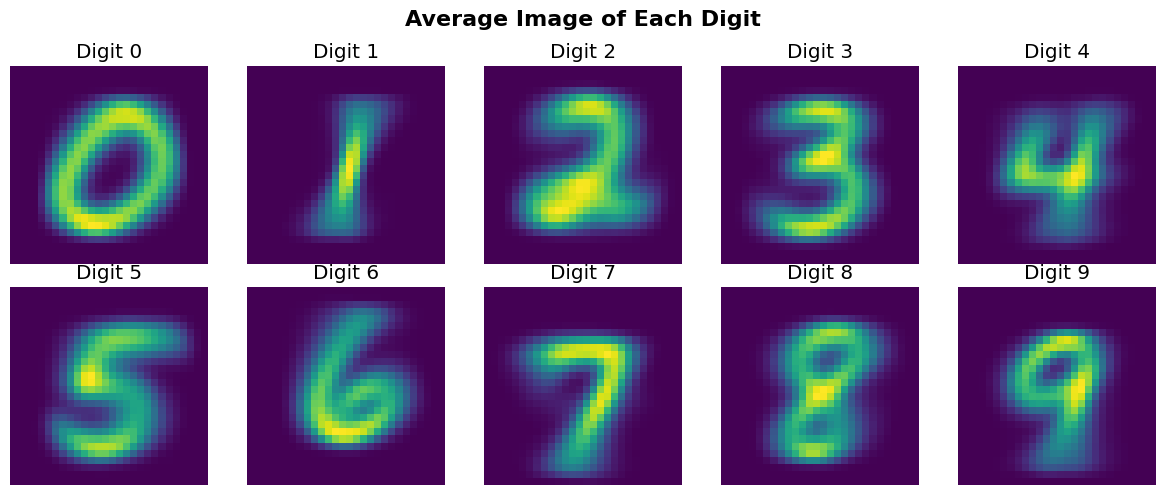

In [12]:
# ============================================================
#          AVERAGE IMAGE OF EACH DIGIT
# ============================================================

fig, axes = plt.subplots(2,5, figsize=(12,5))

fig.suptitle(
    "Average Image of Each Digit",
    fontsize=16,
    fontweight="bold"
)

for digit in range(10):

    average = X[y==digit].mean().values.reshape(28,28)

    axes.flat[digit].imshow(
        average,
        cmap="viridis"
    )

    axes.flat[digit].set_title(f"Digit {digit}")

    axes.flat[digit].axis("off")

plt.tight_layout()

plt.show()

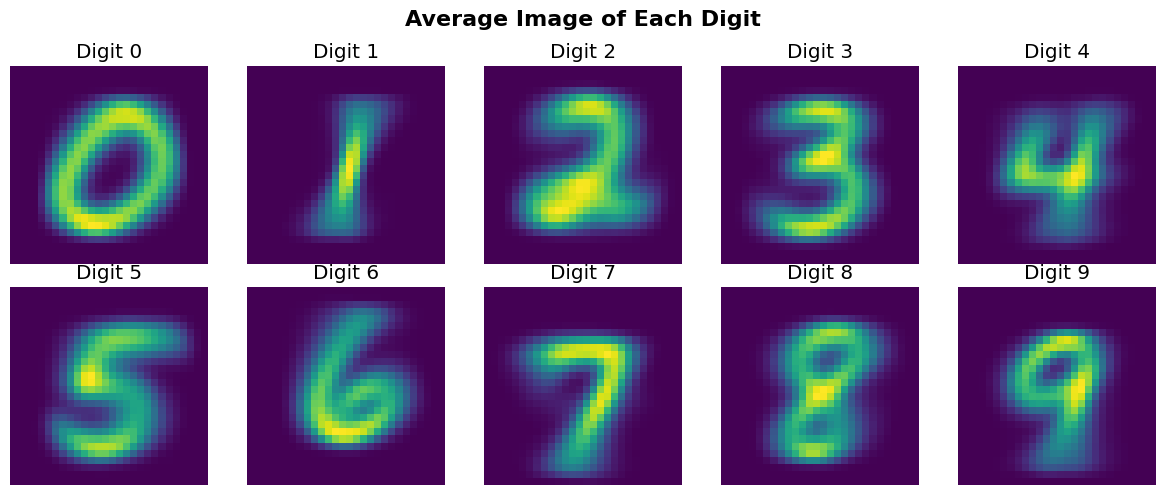

In [13]:
# ============================================================
#          AVERAGE IMAGE OF EACH DIGIT
# ============================================================

fig, axes = plt.subplots(2,5, figsize=(12,5))

fig.suptitle(
    "Average Image of Each Digit",
    fontsize=16,
    fontweight="bold"
)

for digit in range(10):

    average = X[y==digit].mean().values.reshape(28,28)

    axes.flat[digit].imshow(
        average,
        cmap="viridis"
    )

    axes.flat[digit].set_title(f"Digit {digit}")

    axes.flat[digit].axis("off")

plt.tight_layout()

plt.show()

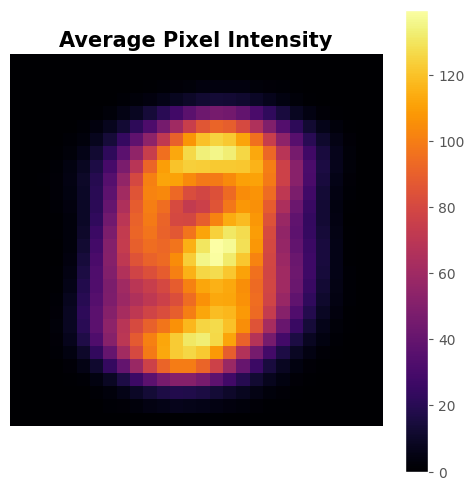

In [14]:
# ============================================================
#          AVERAGE PIXEL HEATMAP
# ============================================================

average_image = X.mean().values.reshape(28,28)

plt.figure(figsize=(6,6))

plt.imshow(
    average_image,
    cmap="inferno"
)

plt.title(
    "Average Pixel Intensity",
    fontsize=15,
    fontweight="bold"
)

plt.colorbar()

plt.axis("off")

plt.show()

# 05 -->> Image Preprocessing

In [15]:
# ============================================================
#               NORMALIZE PIXEL VALUES
# ============================================================

X = X / 255.0

print("=" * 60)
print("Pixel values normalized successfully.")
print(f"Minimum Pixel Value : {X.min().min():.2f}")
print(f"Maximum Pixel Value : {X.max().max():.2f}")
print("=" * 60)

Pixel values normalized successfully.
Minimum Pixel Value : 0.00
Maximum Pixel Value : 1.00


In [16]:
# ============================================================
#                 TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Training Shape   : {X_train.shape}")
print(f"Testing Shape    : {X_test.shape}")
print("=" * 60)

Training Samples : 33600
Testing Samples  : 8400
Training Shape   : (33600, 784)
Testing Shape    : (8400, 784)


In [17]:
# ============================================================
#             CLASS DISTRIBUTION CHECK
# ============================================================

distribution = pd.DataFrame({
    "Training": y_train.value_counts().sort_index(),
    "Testing": y_test.value_counts().sort_index()
})

distribution

,Training,Testing
label,,
0,3305,827
1,3747,937
2,3342,835
3,3481,870
4,3258,814
5,3036,759
6,3310,827
7,3521,880
8,3250,813


# 06 -->> Model Development

In [18]:
# ============================================================
#              DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        gamma="scale"
    )

}

print(f"{len(models)} models are ready for training.")

4 models are ready for training.


In [19]:
# ============================================================
#             TRAINING & MODEL COMPARISON
# ============================================================

results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted"
    )

    results.append({

        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

Training Logistic Regression...
Training K-Nearest Neighbors...
Training Random Forest...
Training Support Vector Machine...


,Model,Accuracy,Precision,Recall,F1 Score
0,Support Vector Machine,0.974167,0.974162,0.974167,0.974154
1,K-Nearest Neighbors,0.966310,0.966700,0.966310,0.966211
2,Random Forest,0.963929,0.963928,0.963929,0.963900
3,Logistic Regression,0.913095,0.912859,0.913095,0.912855


In [20]:
# ============================================================
#              PERFORMANCE SUMMARY
# ============================================================

results_df.style\
.background_gradient(cmap="YlGnBu")\
.format({
    "Accuracy":"{:.4f}",
    "Precision":"{:.4f}",
    "Recall":"{:.4f}",
    "F1 Score":"{:.4f}"
})
print("Everything is ok.\n")

Everything is ok.



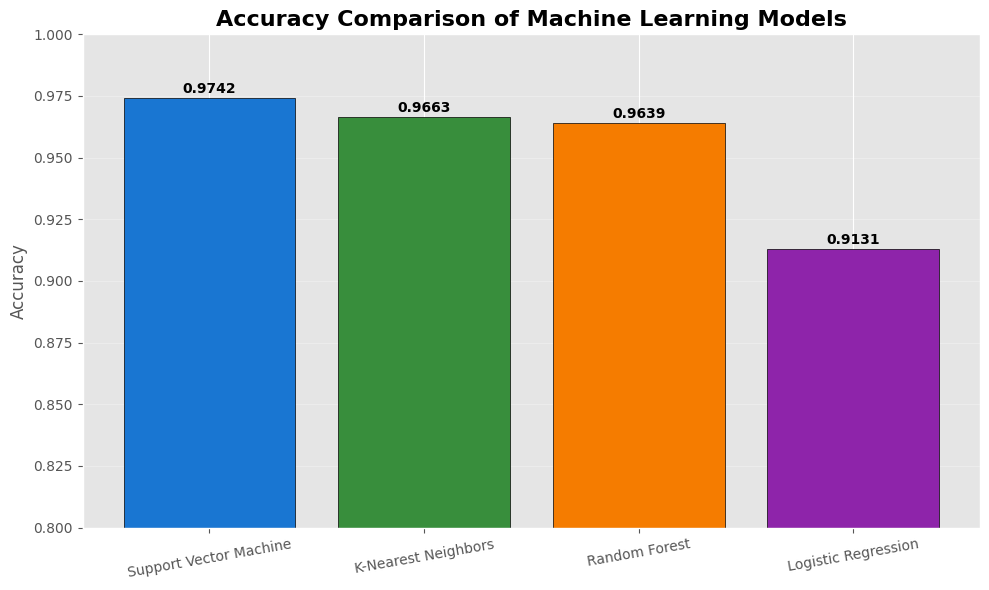

In [21]:
# ============================================================
#             MODEL ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

colors = ["#1976D2",
          "#388E3C",
          "#F57C00",
          "#8E24AA"]

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Accuracy Comparison of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Accuracy")

plt.ylim(0.80,1.00)

plt.grid(axis="y", alpha=0.3)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.002,
        f"{bar.get_height():.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(rotation=10)

plt.tight_layout()

plt.show()

In [22]:
# ============================================================
#                 BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("=" * 60)
print(f"Best Performing Model : {best_model_name}")
print("=" * 60)

Best Performing Model : Support Vector Machine


# 07 -->> Model Evaluation

In [23]:
# ============================================================
#              TRAIN BEST MODEL
# ============================================================

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("=" * 60)
print(f"Best Model : {best_model_name}")
print("=" * 60)

Best Model : Support Vector Machine


In [24]:
# ============================================================
#            CLASSIFICATION REPORT
# ============================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       827
           1       0.99      0.99      0.99       937
           2       0.98      0.98      0.98       835
           3       0.97      0.96      0.97       870
           4       0.98      0.97      0.97       814
           5       0.96      0.96      0.96       759
           6       0.99      0.99      0.99       827
           7       0.97      0.97      0.97       880
           8       0.97      0.97      0.97       813
           9       0.95      0.95      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



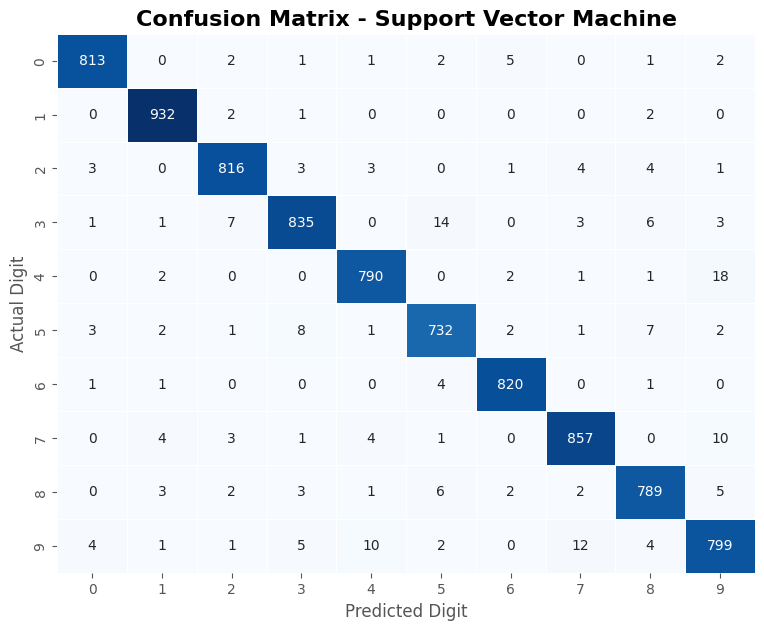

In [25]:
# ============================================================
#               CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=False
)

plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.show()

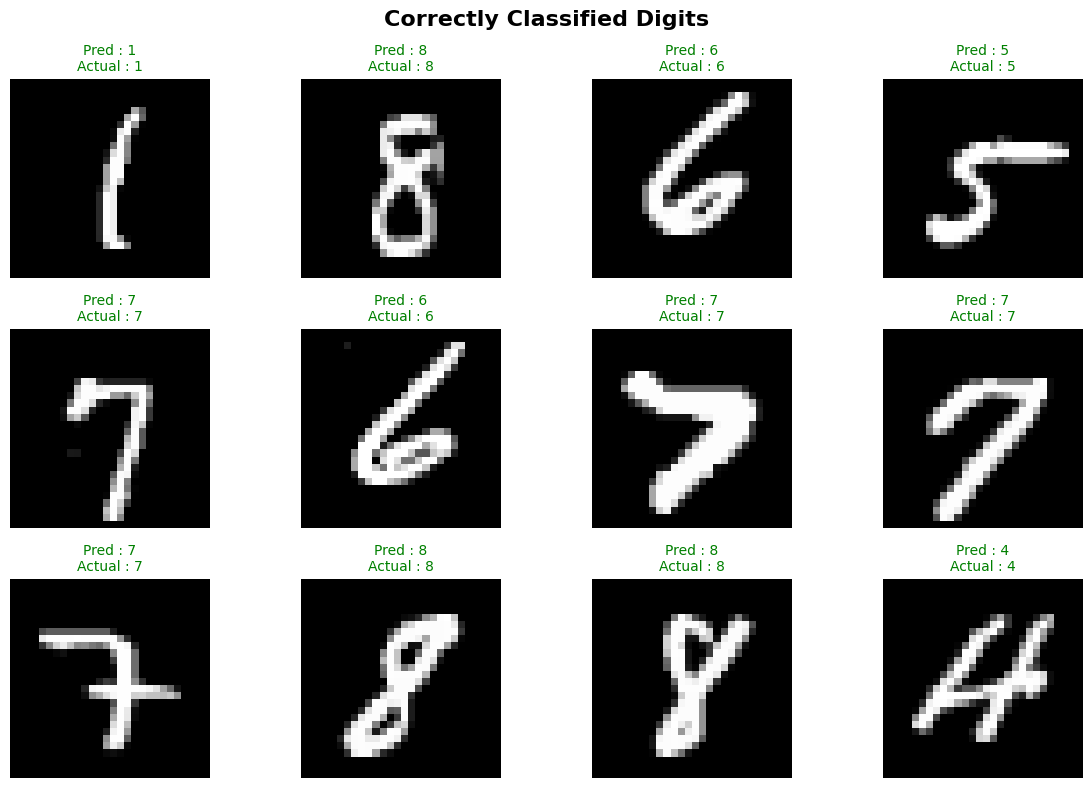

In [26]:
# ============================================================
#           CORRECT PREDICTIONS
# ============================================================

correct = np.where(y_pred == y_test)[0]

plt.figure(figsize=(12,8))

for i, index in enumerate(correct[:12]):

    plt.subplot(3,4,i+1)

    image = X_test.iloc[index].values.reshape(28,28)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Pred : {y_pred[index]}\nActual : {y_test.iloc[index]}",
        color="green",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Correctly Classified Digits",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

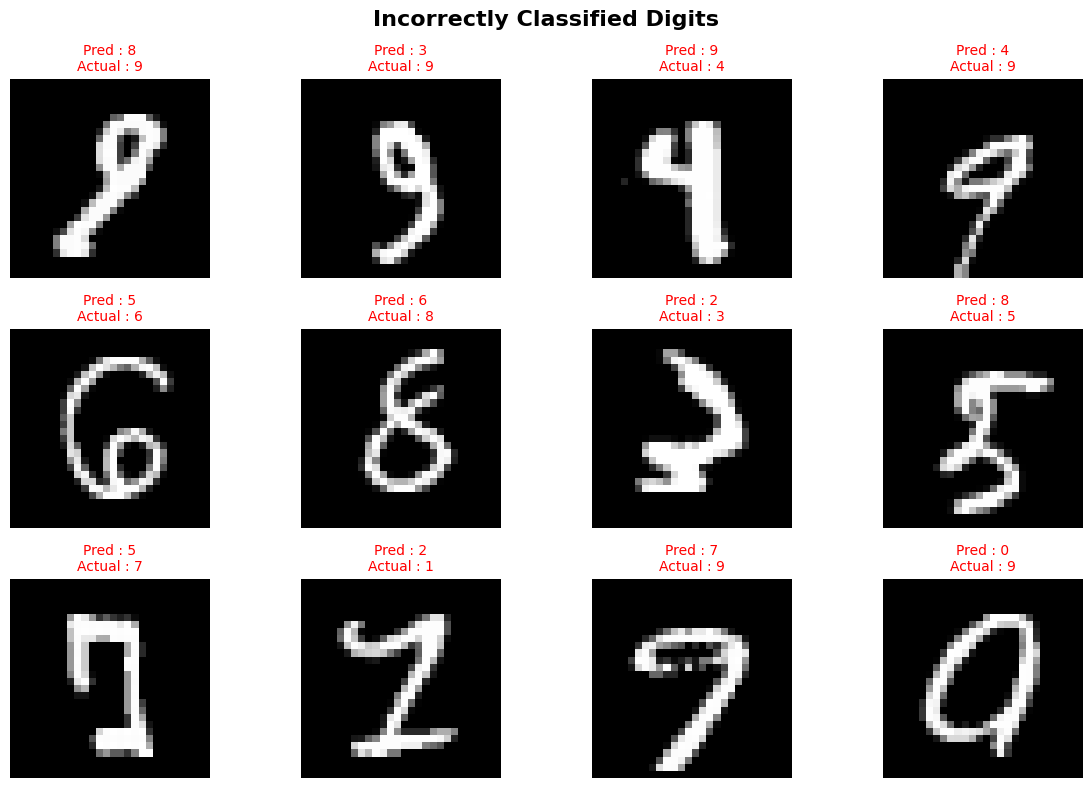

In [27]:
# ============================================================
#           INCORRECT PREDICTIONS
# ============================================================

incorrect = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12,8))

for i, index in enumerate(incorrect[:12]):

    plt.subplot(3,4,i+1)

    image = X_test.iloc[index].values.reshape(28,28)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"Pred : {y_pred[index]}\nActual : {y_test.iloc[index]}",
        color="red",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Incorrectly Classified Digits",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

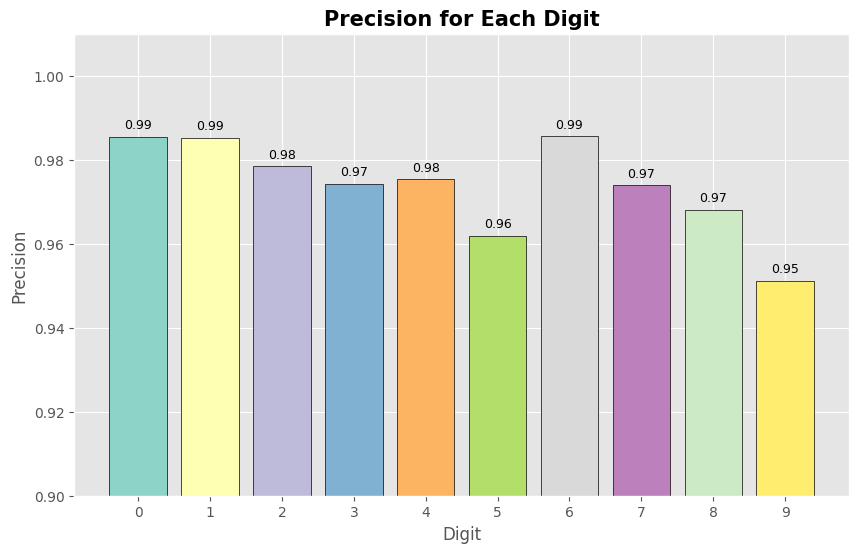

In [28]:
# ============================================================
#          DIGIT-WISE ACCURACY
# ============================================================

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

digit_accuracy = pd.DataFrame(report).transpose().iloc[:10]

plt.figure(figsize=(10,6))

bars = plt.bar(
    digit_accuracy.index,
    digit_accuracy["precision"],
    color=plt.cm.Set3(np.linspace(0,1,10)),
    edgecolor="black"
)

plt.ylim(0.90,1.01)

plt.title(
    "Precision for Each Digit",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Digit")

plt.ylabel("Precision")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.002,
        f"{bar.get_height():.2f}",
        ha="center",
        fontsize=9
    )

plt.show()

In [29]:
print("="*60)
print("Model Evaluation Completed Successfully")
print(f"Best Model : {best_model_name}")
print(f"Overall Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print("="*60)

Model Evaluation Completed Successfully
Best Model : Support Vector Machine
Overall Accuracy : 0.9742


# 08 -->> Predict on New Images

In [30]:
# ============================================================
#              PREPARE TEST DATASET
# ============================================================

# Normalize pixel values
test_data = test_df / 255.0

print("=" * 60)
print("Test Dataset Shape :", test_data.shape)
print("=" * 60)

Test Dataset Shape : (28000, 784)


In [31]:
# ============================================================
#              PREDICT TEST IMAGES
# ============================================================

test_predictions = best_model.predict(test_data)

print("=" * 60)
print("Prediction Completed Successfully")
print("=" * 60)

Prediction Completed Successfully


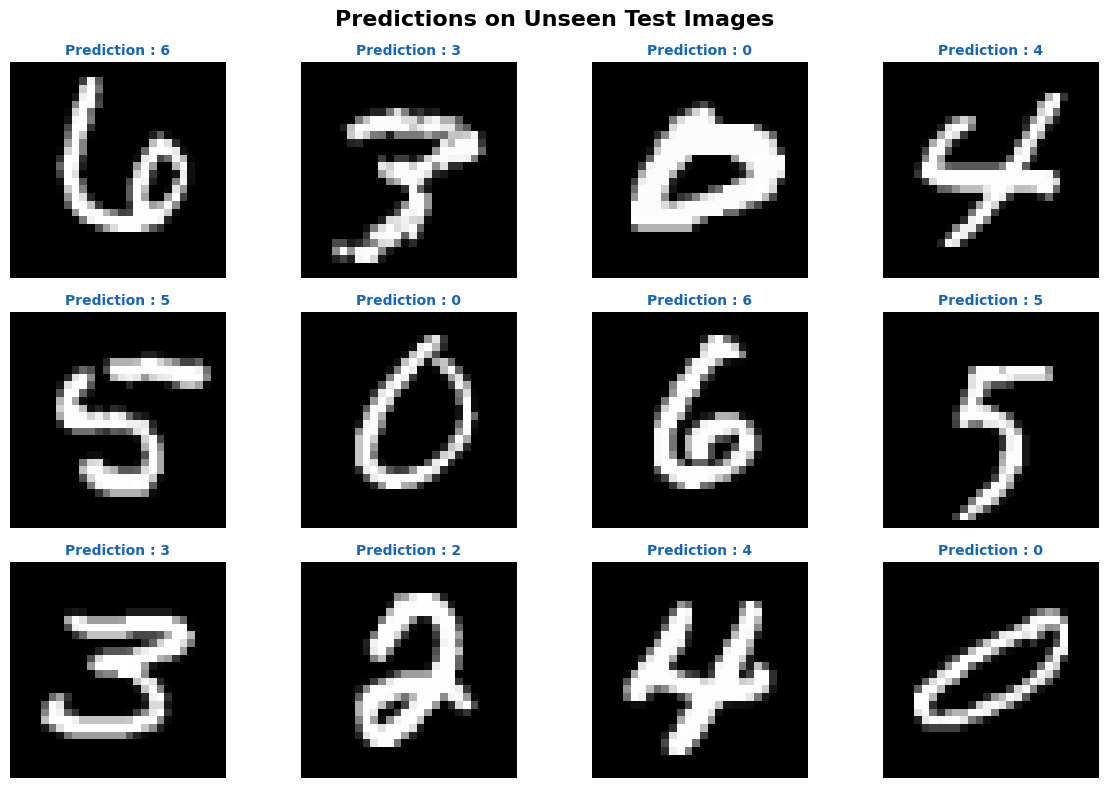

In [32]:
# ============================================================
#          RANDOM TEST IMAGE PREDICTIONS
# ============================================================

plt.figure(figsize=(12,8))

random_index = np.random.choice(len(test_data),12)

for i,index in enumerate(random_index):

    plt.subplot(3,4,i+1)

    image = test_data.iloc[index].values.reshape(28,28)

    plt.imshow(image,cmap="gray")

    plt.title(
        f"Prediction : {test_predictions[index]}",
        fontsize=10,
        fontweight="bold",
        color="#1565C0"
    )

    plt.axis("off")

plt.suptitle(
    "Predictions on Unseen Test Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# 09 -->> Save & Load Best Model

In [33]:
# ============================================================
#                SAVE BEST MODEL
# ============================================================

import joblib

joblib.dump(best_model,"mnist_digit_classifier.pkl")

print("="*60)
print("Model Saved Successfully")
print(f"Best Model : {best_model_name}")
print("File Name  : mnist_digit_classifier.pkl")
print("="*60)

Model Saved Successfully
Best Model : Support Vector Machine
File Name  : mnist_digit_classifier.pkl


In [34]:
# ============================================================
#                LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load("mnist_digit_classifier.pkl")

print("="*60)
print("Model Loaded Successfully")
print(type(loaded_model))
print("="*60)

Model Loaded Successfully
<class 'sklearn.svm._classes.SVC'>


In [35]:
# ============================================================
#          VERIFY SAVED MODEL
# ============================================================

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

actual = y_test.iloc[0]

print("="*60)

print(f"Actual Digit    : {actual}")

print(f"Predicted Digit : {prediction[0]}")

print("="*60)

Actual Digit    : 1
Predicted Digit : 1


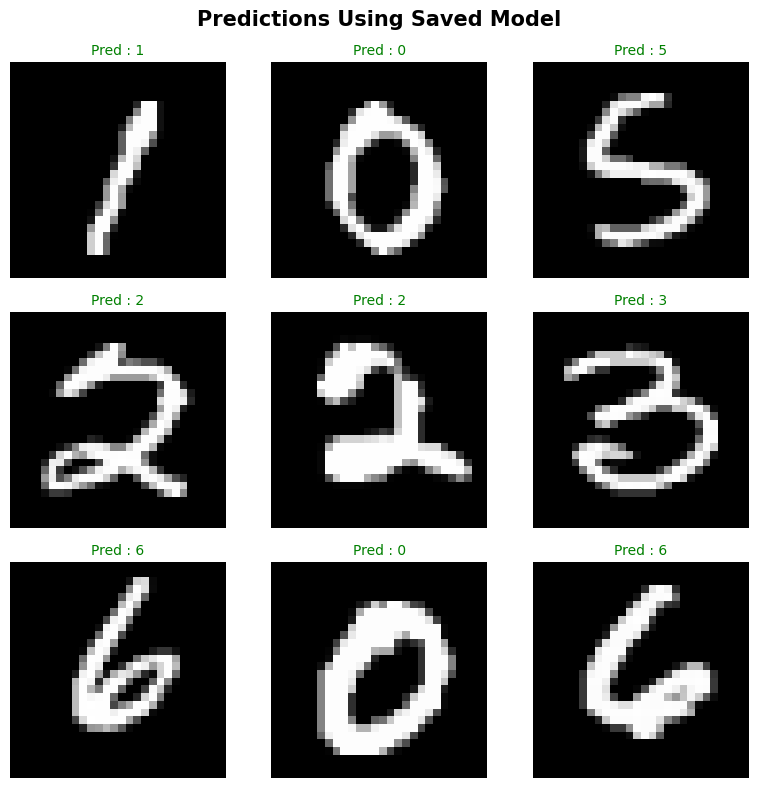

In [36]:
# ============================================================
#           VERIFY MULTIPLE PREDICTIONS
# ============================================================

sample_images = X_test.sample(9, random_state=42)

sample_predictions = loaded_model.predict(sample_images)

plt.figure(figsize=(8,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    image = sample_images.iloc[i].values.reshape(28,28)

    plt.imshow(image,cmap="gray")

    plt.title(
        f"Pred : {sample_predictions[i]}",
        color="green",
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Predictions Using Saved Model",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# 10 --->>> Generate Kaggle Submission File

In [37]:
# ============================================================
#           GENERATE SUBMISSION FILE
# ============================================================

submission = pd.DataFrame({

    "ImageId": np.arange(1, len(test_predictions)+1),

    "Label": test_predictions

})

submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [38]:
# ============================================================
#            SAVE SUBMISSION FILE
# ============================================================

submission.to_csv(
    "submission.csv",
    index=False
)

print("="*60)
print("submission.csv created successfully.")
print("="*60)

submission.csv created successfully.
